# Exploratory Data Analysis — Kickstarter Campaigns
**Group_ID-13** · Words That Fund: Linguistic Patterns in Crowdfunding Campaign Success

### Outline
1. Setup & Data Loading
2. Dataset Overview
3. Missing Values & Data Quality
4. Category Analysis
5. Funding Goal Distribution
6. Pledged Amount Distribution
7. Goal vs. Pledged (by outcome)
8. Description Length Analysis
9. Description Length vs. Amount Funded


## 1. Setup & Data Loading

In [2]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 4)})

BLUE, RED, PALETTE = "#477ADA", "#D65F5F", ["#4878CF", "#D65F5F"]


In [3]:
df = pd.read_csv("Kickstarter_processed (3).csv", index_col=0)

# Parse token lists
def parse_tokens(cell):
    try:
        return ast.literal_eval(cell)
    except Exception:
        return []

df["tokens"]    = df["description_processed"].apply(parse_tokens)
df["token_count"] = df["tokens"].apply(len)

# Description length in characters and words
df["desc_char_len"] = df["description"].str.len()
df["desc_word_len"] = df["description"].str.split().str.len()

# Human-readable outcome label
df["outcome"] = df["status"].map({1: "Successful", 0: "Failed"})

print(f"Shape: {df.shape}")
#df.head(3)


Shape: (6507, 19)


## 2. Dataset Overview

In [4]:
print("=== Column Types ===")
print(df.dtypes)
print()
print("=== Numeric Summary ===")
display(df[["pledged", "goal", "reached", "desc_char_len", "desc_word_len", "token_count"]].describe().round(2))


=== Column Types ===
title                        object
description                  object
pledged                     float64
usd_pledged                 float64
converted_pledged_amount      int64
goal                        float64
currency                     object
category                     object
video                         int64
reached                     float64
status                        int64
duration                      int64
description_processed        object
pos_tagged                   object
tokens                       object
token_count                   int64
desc_char_len                 int64
desc_word_len                 int64
outcome                      object
dtype: object

=== Numeric Summary ===


,pledged,goal,reached,desc_char_len,desc_word_len,token_count
count,6507.00,6507.00,6507.00,6507.00,6507.00,6507.00
mean,48638.33,25361.36,227.30,5769.14,968.26,436.82
std,318963.56,45934.45,1135.94,4468.98,742.86,347.83
min,56.00,5001.00,0.20,802.00,101.00,32.00
25%,3226.50,9000.00,16.67,2620.00,445.50,192.50
50%,10459.00,13000.00,102.84,4504.00,757.00,337.00
75%,24345.00,25000.00,124.48,7526.50,1259.50,574.00
max,18649456.00,1000000.00,41290.95,35273.00,6237.00,2895.00


## 3. Missing Values & Data Quality

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
quality = quality[quality["missing_count"] > 0]

if quality.empty:
    print("✓ No missing values found in any column.")
else:
    display(quality)

# Duplicates
dupes = df.duplicated(subset=["description"]).sum()
print(f"Duplicate descriptions: {dupes}")

# Currency
print(f"Currencies present: {df['currency'].value_counts().to_dict()}")


,missing_count,missing_%
title,50,0.77


Duplicate descriptions: 0
Currencies present: {'USD': 6507}


## 4. Category Analysis

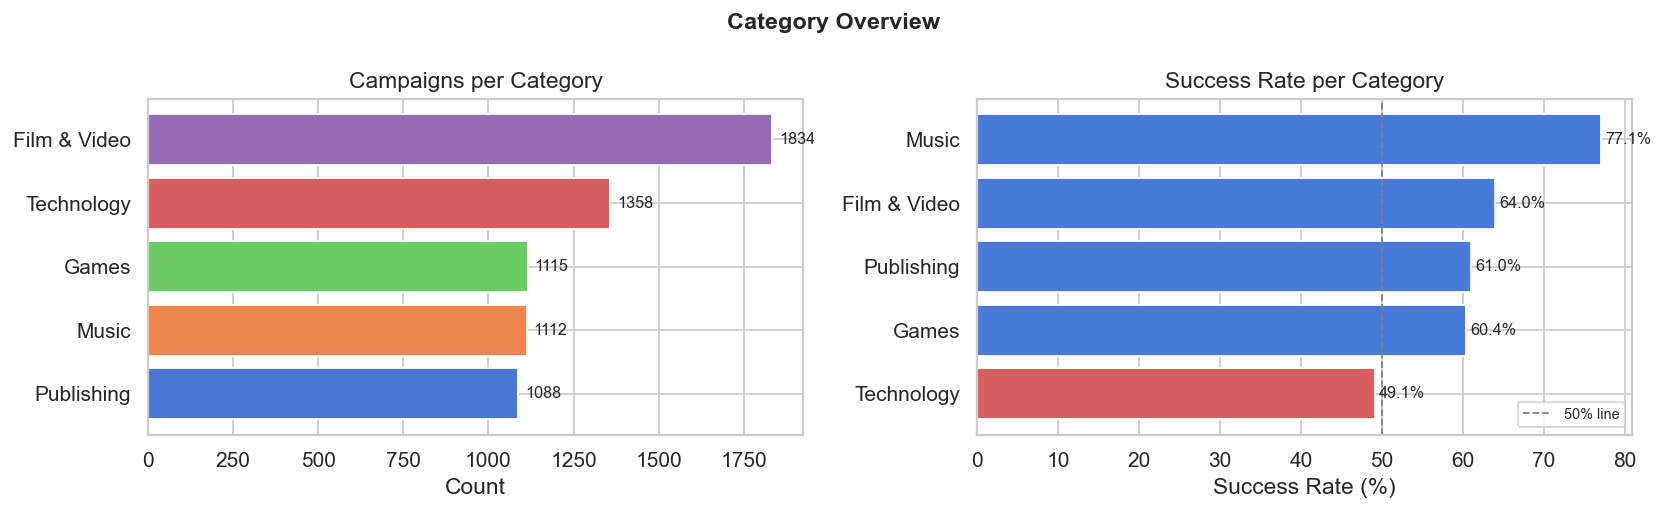

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Campaign count per category
cat_counts = df["category"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
             color=sns.color_palette("muted", len(cat_counts)), edgecolor="white")
for i, v in enumerate(cat_counts.values[::-1]):
    axes[0].text(v + 20, i, str(v), va="center", fontsize=9)
axes[0].set_title("Campaigns per Category")
axes[0].set_xlabel("Count")

# Success rate per category
sr = df.groupby("category")["status"].mean().sort_values() * 100
colors = [BLUE if v >= 50 else RED for v in sr.values]
axes[1].barh(sr.index, sr.values, color=colors, edgecolor="white")
axes[1].axvline(50, color="grey", linestyle="--", linewidth=1, label="50% line")
for i, v in enumerate(sr.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
axes[1].set_title("Success Rate per Category")
axes[1].set_xlabel("Success Rate (%)")
axes[1].legend(fontsize=8)

plt.suptitle("Category Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_02_category_overview.png", bbox_inches="tight")
plt.show()


### Figure interpretation - Category Overview

Film & Video has the highest number of campaigns, followed by Technology, Games, Music, and Publishing, as shown in the left panel.
The right panel shows success rates by category. Music has the highest success rate, followed by Film & Video, then Publishing and Games at similar levels, while Technology ranks last and is the only category below the 50% threshold. All other categories exceed this benchmark.

## 5. Funding Goal Distribution

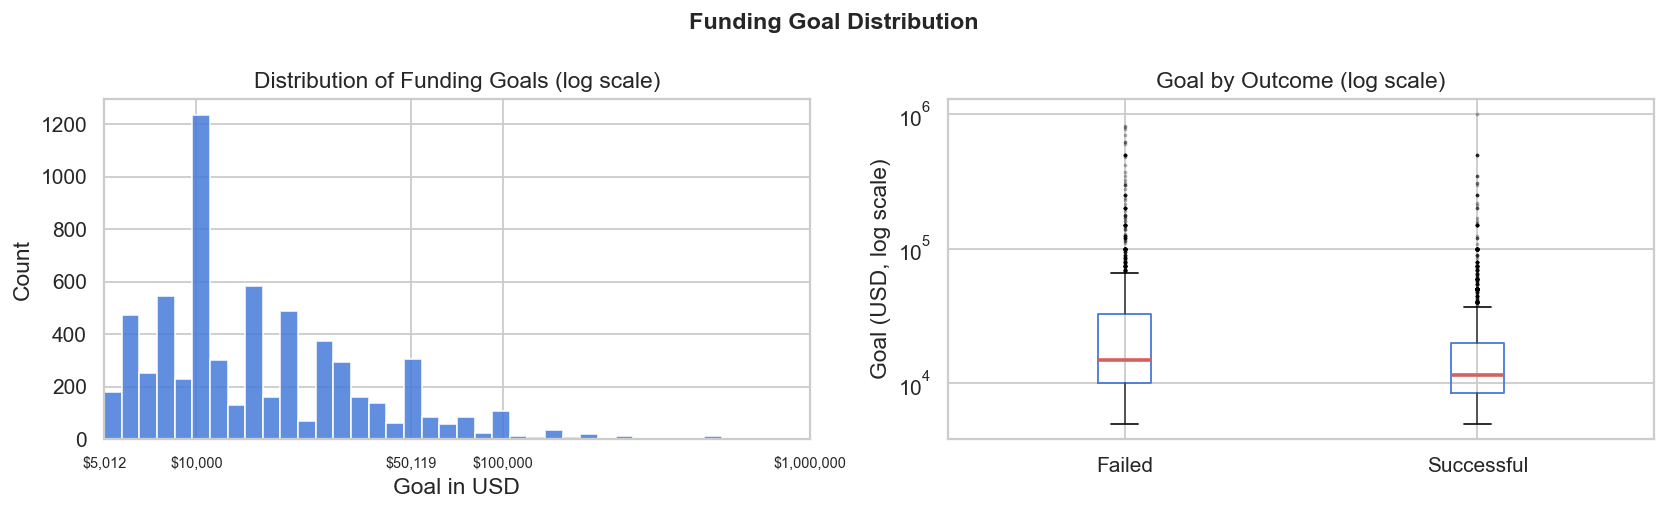

Median goal — Successful: $11,500  |  Failed: $15,000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log10(df["goal"]), bins=40, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Goal in USD")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Funding Goals (log scale)")
axes[0].margins(x=0)

xt = [3.7, 4, 4.7, 5, 6]   # ← starts at 3.7 (~$5,000) instead of 3 ($1,000)
axes[0].set_xticks(xt)
axes[0].set_xticklabels([f"${10**x:,.0f}" for x in xt], fontsize=8)
# Box plot by outcome
df.boxplot(column="goal", by="outcome", ax=axes[1],
           boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
axes[1].set_yscale("log")
axes[1].set_title("Goal by Outcome (log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Goal (USD, log scale)")
plt.suptitle("")

plt.suptitle("Funding Goal Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_04_goal_distribution.png", bbox_inches="tight")
plt.show()

print("Median goal — Successful: ${:,.0f}  |  Failed: ${:,.0f}".format(
    df[df.status==1]["goal"].median(),
    df[df.status==0]["goal"].median()
))


### Figure interpretation — Funding Goal Distribution

The distribution of funding goals is right-skewed, with most values concentrated in the lower range—approximately between 5,000 and 25,000 USD—and a long tail extending toward much higher amounts. Because of this skewness, the mean is less informative, as it is influenced by extreme values, while the median and the visual concentration in the histogram better capture the typical range.
By outcome, successful campaigns have a lower median goal (11,500) compared to failed campaigns (15,000). The boxplot also indicates that failed campaigns exhibit greater dispersion and more high-value outliers, suggesting that higher and more variable funding targets are more commonly associated with unsuccessful outcomes.

## 6. Pledged Amount Distribution

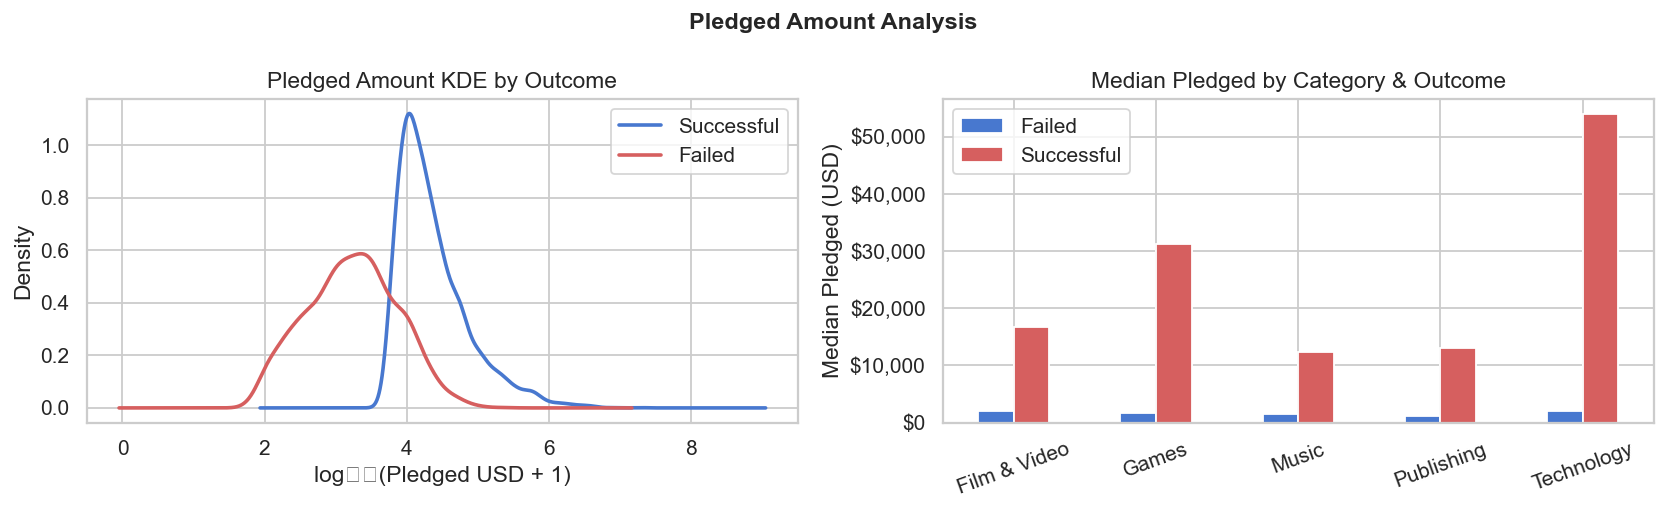

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE by outcome on log scale
for label, color in zip(["Successful", "Failed"], PALETTE):
    sub = np.log10(df[df["outcome"] == label]["pledged"] + 1)
    sub.plot.kde(ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_xlabel("log₁₀(Pledged USD + 1)")
axes[0].set_title("Pledged Amount KDE by Outcome")
axes[0].legend()

# Median pledged per category
med_pledged = df.groupby(["category","outcome"])["pledged"].median().unstack()
med_pledged.plot(kind="bar", color=PALETTE, ax=axes[1], edgecolor="white")
axes[1].set_title("Median Pledged by Category & Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Pledged (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.suptitle("Pledged Amount Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_05_pledged_distribution.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Pledged Amount Analysis

The left panel shows KDE curves of log₁₀(pledged + 1) by outcome. Successful campaigns display a broad distribution with a peak around log ~4–5 (i.e., $10k$–$100k$), while Failed campaigns are heavily concentrated near zero, indicating that most unsuccessful projects attracted only minimal backing. The right panel is a grouped bar chart of median pledged amounts by category and outcome. Across all five categories, the gap between successful and failed campaigns is substantial. Technology and Games show the highest median pledged amounts among successful campaigns, whereas failed campaigns remain well below the $10,000 median pledged regardless of category.

## 7. Goal vs. Pledged


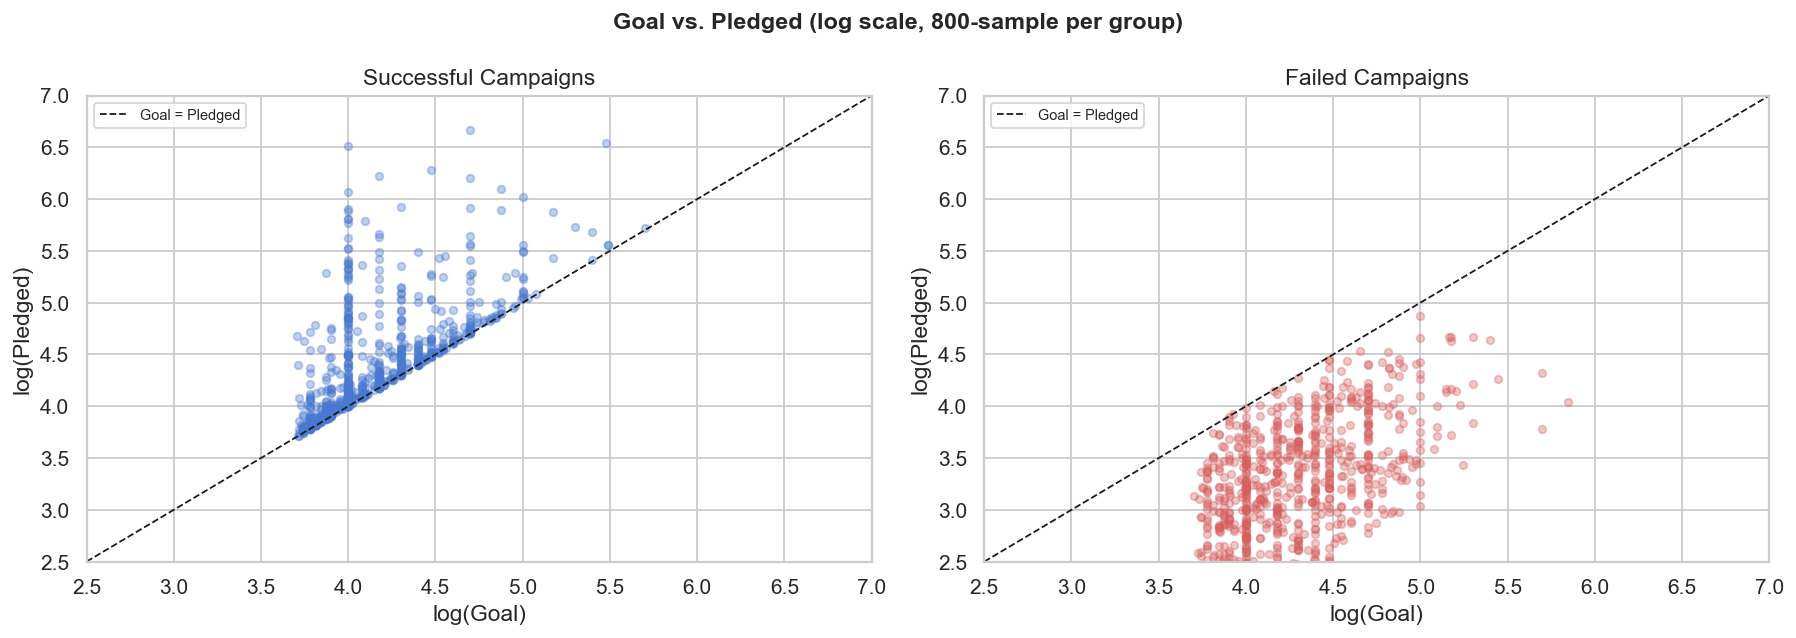

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, color) in zip(axes, zip(["Successful","Failed"], PALETTE)):
    sub = df[df["outcome"] == label].sample(min(800, len(df)), random_state=42)
    ax.scatter(np.log10(sub["goal"]+1), np.log10(sub["pledged"]+1),
               alpha=0.35, s=18, color=color)
    # identity line
    lims = [2.5, 7]
    ax.plot(lims, lims, "k--", linewidth=1, label="Goal = Pledged")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("log(Goal)")
    ax.set_ylabel("log(Pledged)")
    ax.set_title(f"{label} Campaigns")
    ax.legend(fontsize=8)

plt.suptitle("Goal vs. Pledged (log scale, 800-sample per group)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_07_goal_vs_pledged.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Goal vs. Pledged Scatter Plot (log scale, 800-sample per group)

Both panels plot log(goal) on the x-axis and log(pledged) on the y-axis, with the diagonal representing equality between the two.
For successful campaigns, points lie mostly on or above the diagonal, indicating that pledged amounts meet or exceed the goal. Many observations cluster close to the line, suggesting that projects often reach their target with limited excess, while a smaller number outperform it by a wider margin.
For failed campaigns, points are predominantly below the diagonal, showing that pledged amounts fall short of the target. This pattern holds across the full range of goals, indicating systematic underperformance relative to the stated objective rather than only a concentration at very low pledged values.
The contrast between the two panels reflects the definition of campaign outcome itself, as success is determined by whether pledged funding reaches or exceeds the goal.

## 8. Description Length Analysis

We measure description length two ways:
- **Character count** — total characters in the raw description
- **Word count** — whitespace-split word tokens


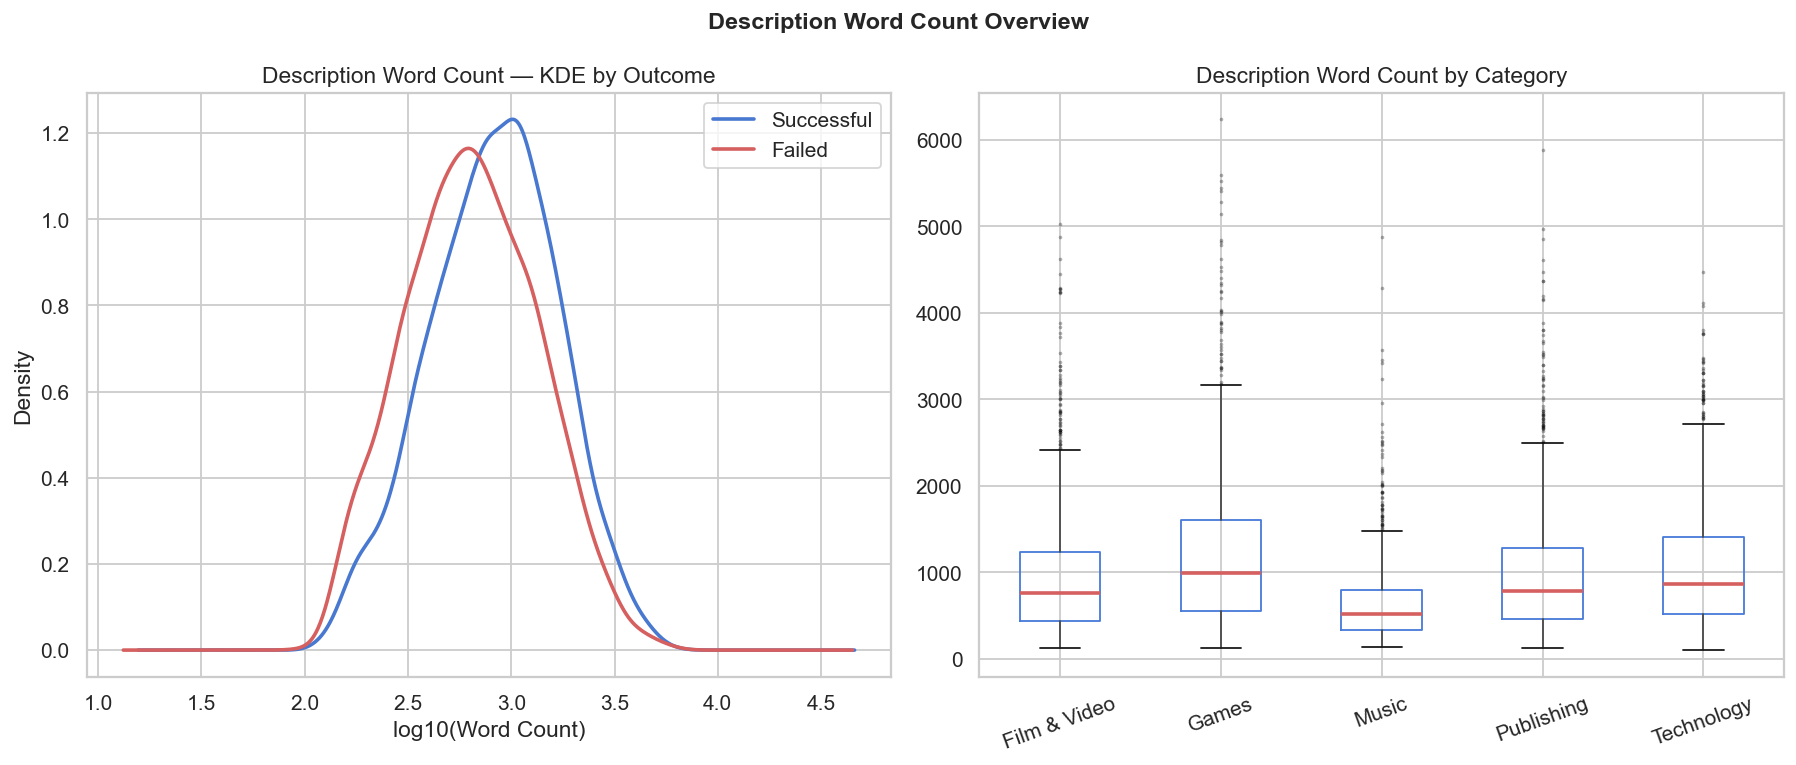


=== Description Word Count by Outcome ===


,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
Failed,2473.0,840.5,681.6,101.0,377.0,631.0,1084.0,5881.0
Successful,4034.0,1046.6,767.7,115.0,500.0,842.5,1359.8,6237.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

col = "desc_word_len"
label = "Word Count"

# KDE by outcome
for outcome, color in zip(["Successful", "Failed"], PALETTE):
    vals = np.log10(df[df["outcome"] == outcome][col].clip(lower=1))
    vals.plot.kde(ax=axes[0], label=outcome, color=color, linewidth=2)

axes[0].set_xlabel(f"log10({label})")
axes[0].set_title(f"Description {label} — KDE by Outcome")
axes[0].legend()

# Box plot by category
df.boxplot(column=col, by="category", ax=axes[1],
           boxprops=dict(color=BLUE),
           medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))

axes[1].set_title(f"Description {label} by Category")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Description Word Count Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== Description Word Count by Outcome ===")
display(df.groupby("outcome")["desc_word_len"].describe().round(1))

### Figure interpretation — Description Word Count Overview

The left panel shows the distribution of log-transformed description length by outcome. The two curves largely overlap, but the distribution for successful campaigns is shifted to the right, indicating longer descriptions on average. This is consistent with the summary statistics, where both the mean and median are higher for successful campaigns, confirming a systematic difference rather than being driven by outliers.
The right panel shows the distribution of raw description length across categories. Games and Technology have higher medians and greater dispersion, suggesting longer and more variable descriptions. Music shows shorter and more concentrated descriptions, while Film & Video and Publishing lie in between, with moderate central values and variability.

## 9. Description Length vs. Amount Funded

We examine whether longer campaign descriptions are associated with higher pledged amounts,
using both scatter plots and binned median plots for a cleaner signal.
Statistical tests (Pearson & Spearman correlations) are reported for each group.

There is a modest positive correlation between description length and amount funded overall, with a non-linear relationship that differs by category. The correlation coefficient is higher for failed projects in certain categories (notably *Technology* and *Publishing*), indicating that description length alone cannot predict success and that other structural factors drive backing.

*Technology* shows the highest overall Spearman ρ (0.393) and the highest correlation among failed campaigns (0.377), suggesting that in this category backer engagement is more sensitive to description length regardless of outcome.

In [12]:
def annotate_corr(ax, x, y, loc=(0.04, 0.93)):
    mask = np.isfinite(x) & np.isfinite(y)
    r_p, p_p = stats.pearsonr(x[mask], y[mask])
    r_s, p_s = stats.spearmanr(x[mask], y[mask])
    
    # Use parentheses to wrap the multi-line string
    txt = (
        f"Pearson r = {r_p:+.3f} (p={'<0.001' if p_p<0.001 else f'{p_p:.3f}'})\n"
        f"Spearman ρ = {r_s:+.3f} (p={'<0.001' if p_s<0.001 else f'{p_s:.3f}'})"
    )
    
    ax.text(*loc, txt, transform=ax.transAxes, fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))


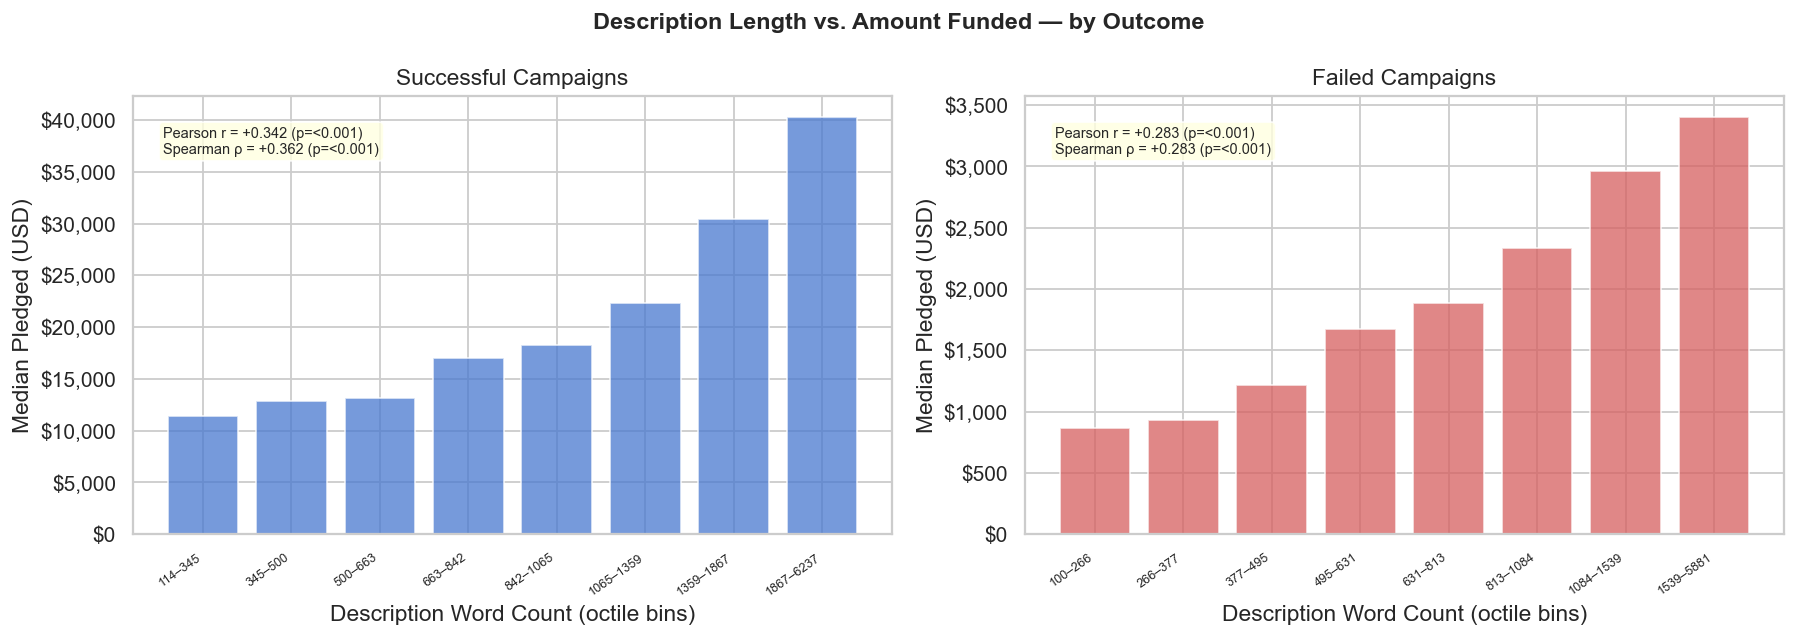

In [13]:
# ── Fig B: Same analysis split by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, outcome, color in zip(axes, ["Successful","Failed"], PALETTE):
    sub = df[df["outcome"]==outcome].copy()
    sub["word_len_bin"] = pd.qcut(sub["desc_word_len"], q=8, duplicates="drop")
    bstats = sub.groupby("word_len_bin", observed=True).agg(
        median_pledged=("pledged","median"),
        n=("pledged","count")
    ).reset_index()

    ax.bar(range(len(bstats)), bstats["median_pledged"],
           color=color, alpha=0.75, edgecolor="white")
    ax.set_xticks(range(len(bstats)))
    ax.set_xticklabels(
        [f"{int(b.left)}–{int(b.right)}" for b in bstats["word_len_bin"]],
        rotation=35, ha="right", fontsize=7
    )
    ax.set_xlabel("Description Word Count (octile bins)")
    ax.set_ylabel("Median Pledged (USD)")
    ax.set_title(f"{outcome} Campaigns")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    # correlation within this group
    annotate_corr(ax,
                  np.log10(sub["desc_word_len"].clip(lower=1).values),
                  np.log10(sub["pledged"].clip(lower=1).values))

plt.suptitle("Description Length vs. Amount Funded — by Outcome",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_10_desc_len_vs_pledged_by_outcome.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Description Length vs. Amount Funded by Outcome (octile-binned bar charts)

For successful campaigns, the median pledged amount increases steadily with description length across all bins. The upward trend is consistent, with longer descriptions associated with higher funding levels, and no clear evidence of a strong plateau in the upper bins. At most, the growth may slightly moderate at the highest lengths.

For failed campaigns, a positive relationship is also present: median pledged amounts tend to rise as descriptions get longer. However, the increase is more gradual and occurs at much lower funding levels, indicating that while description length still matters, its impact is substantially weaker in economic terms compared to successful campaigns.

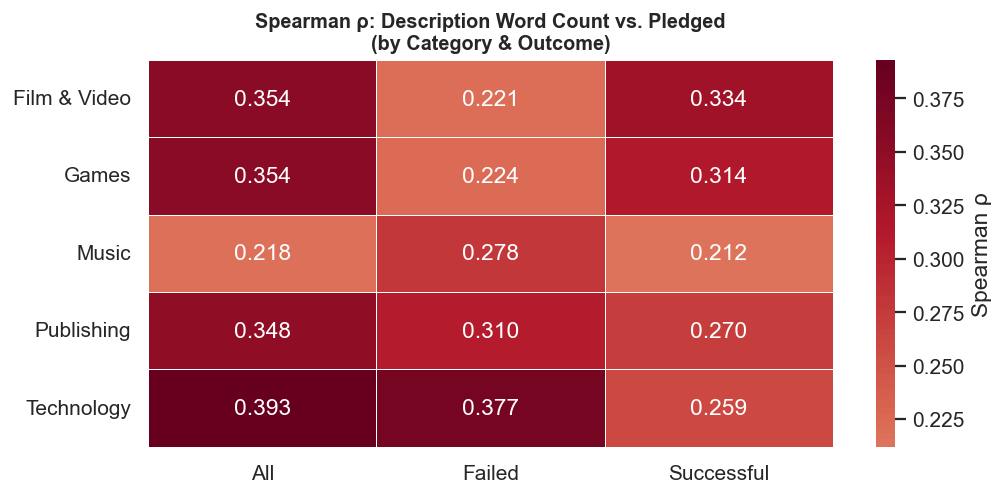


Full correlation table:


,category,group,spearman_rho
0,Film & Video,All,0.354
1,Film & Video,Failed,0.221
2,Film & Video,Successful,0.334
3,Games,All,0.354
4,Games,Failed,0.224
5,Games,Successful,0.314
6,Music,All,0.218
7,Music,Failed,0.278
8,Music,Successful,0.212
9,Publishing,All,0.348


In [4]:
# ── Fig C: Per-category correlation heatmap
corr_rows = []
for cat in df["category"].unique():
    for outcome in ["Successful", "Failed", "All"]:
        sub = df[df["category"]==cat] if outcome=="All" else df[(df["category"]==cat)&(df["outcome"]==outcome)]
        if len(sub) < 30:
            continue
        x = np.log10(sub["desc_word_len"].clip(lower=1))
        y = np.log10(sub["pledged"].clip(lower=1))
        r, p = stats.spearmanr(x, y)
        corr_rows.append({"category": cat, "group": outcome, "spearman_rho": round(r,3)})

corr_df = pd.DataFrame(corr_rows)
pivot = corr_df.pivot(index="category", columns="group", values="spearman_rho")

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", center=0,
            cmap="RdBu_r", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Spearman ρ"})
ax.set_title("Spearman ρ: Description Word Count vs. Pledged\n(by Category & Outcome)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("eda_11_corr_heatmap.png", bbox_inches="tight")
plt.show()

print("\nFull correlation table:")
display(corr_df.sort_values(["category","group"]).reset_index(drop=True))


### Figure interpretation — Spearman ρ Heatmap (Description Word Count vs. Pledged, by Category & Outcome)

The heatmap shows that the Spearman correlation between description length and pledged amount is positive and statistically significant across all categories and groups. The magnitude of the correlation is generally moderate, with most values falling between approximately 0.2 and 0.4.
Comparing outcomes, there is no uniform pattern indicating that the relationship is systematically stronger for either successful or failed campaigns. In some categories (such as Technology and Publishing), the correlation is higher among failed campaigns, whereas in others (such as Film & Video and Games), successful campaigns display stronger associations. This indicates that the strength of the relationship varies by category rather than being driven consistently by campaign outcome.